In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Initial information

Country: Spain

Year: 2011

Technologies:
    - Solar
    - Wind
    - CCGT (gas turbine)
    - Coal
    - Hydro (battery)

## Technologies data and costs
The technology cost and performance assumptions are taken from the PyPSA Technology Data database (PyPSA/technology-data, v0.11.0). 

This database compiles assumptions and projections for a wide range of energy system technologies for different years. The data can be imported into Python and loaded into a pandas.DataFrame. 

In [2]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [3]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # Assign the natural gas fuel cost to the CCGT technology (fuel prices are stored under "gas" in the database)

In [4]:
#calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [5]:
#calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

In [6]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [7]:
#calculate capital cost
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [8]:
technologies = ["onwind", "solar", "CCGT", "coal", "PHS"]

data = {
    "Capital cost (EUR/MW/a)": [costs.at[t, "capital_cost"] for t in technologies],
    "Marginal cost (EUR/MWh)": [costs.at[t, "marginal_cost"] for t in technologies],
}

cost_table = pd.DataFrame(data, index=technologies)

cost_table

,Capital cost (EUR/MW/a),Marginal cost (EUR/MWh)
onwind,101644.123324,1.428600
solar,51346.829820,0.010600
CCGT,104788.020783,46.803121
coal,337208.027448,30.098840
PHS,182698.734592,0.000000


## Data
For this project, time series data are required for the wind and solar capacity factors, as well as for electricity demand. The datasets used include:
-  Time series of wind capacity factors for European countries
- Time series of solar capacity factors for European countries
- Electricity demand time series

In [9]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

In [10]:
data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# For this project the chosen country was Spain
country = 'ESP'

## Question A
- Dispatch time series for a week in summer and winter

- Annual electricity mix

- Technologies duration curves

## Joint capacity and dispatch optimization

In [12]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq=None)

In [13]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green"], # colors that represent each carrier
)

In [14]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

<Axes: xlabel='snapshot', ylabel='MW'>

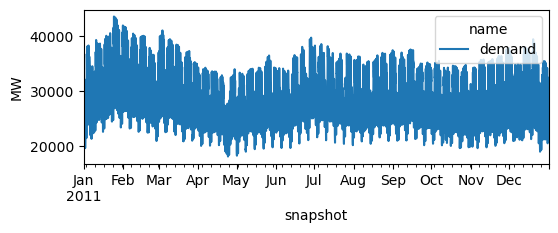

In [15]:
#create a plot with the hourly demand in 2011
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

In [16]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=25300, # 25.3 GW
)

# coal
n.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=11700, # 11.7 GW
)

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Onshore wind
n.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Solar PV
n.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )


# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

<Axes: xlabel='snapshot', ylabel='CF'>

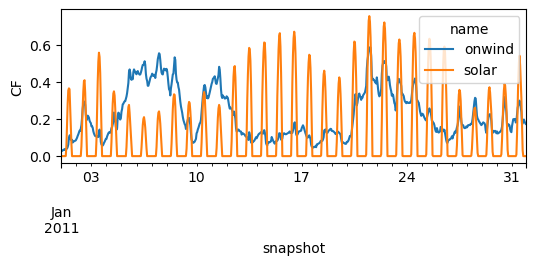

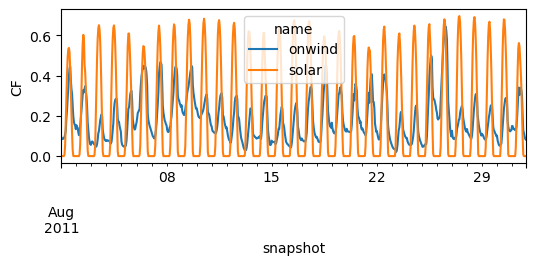

In [17]:
# capacity factors of wind and solar during January 2011 (winter)
n.generators_t.p_max_pu.loc["2011-01"].plot(figsize=(6, 2), ylabel="CF") 

# capacity factors of wind and solar during August 2011 (winter)
n.generators_t.p_max_pu.loc["2011-08"].plot(figsize=(6, 2), ylabel="CF") 

In [18]:
for df in [n.buses, n.loads, n.generators]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n.buses.index = pd.Index(n.buses.index.tolist(), dtype=object)
n.loads.index = pd.Index(n.loads.index.tolist(), dtype=object)
n.generators.index = pd.Index(n.generators.index.tolist(), dtype=object)

n.buses.index.name = "name"
n.loads.index.name = "name"
n.generators.index.name = "name"

## Model PyPSA

In [19]:
n.optimize(solver_name="highs")
# PyPS decides two things at the same time: capacity (how much technology to build) and dispatch (how much each generator produces in every hour of the year)

Index(['Spain electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 74.44it/s]
INFO:linopy.io: Writing time: 0.85s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78846 duals
Objective: 1.85e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [20]:
# how much capacity the model decided to build (optimised capacities in GW)
n.generators.p_nom_opt.div(1e3)

name
CCGT      25.300000
coal      11.700000
onwind    70.337209
solar      7.242738
Name: p_nom_opt, dtype: float64

In [21]:
dispatch = n.generators_t.p

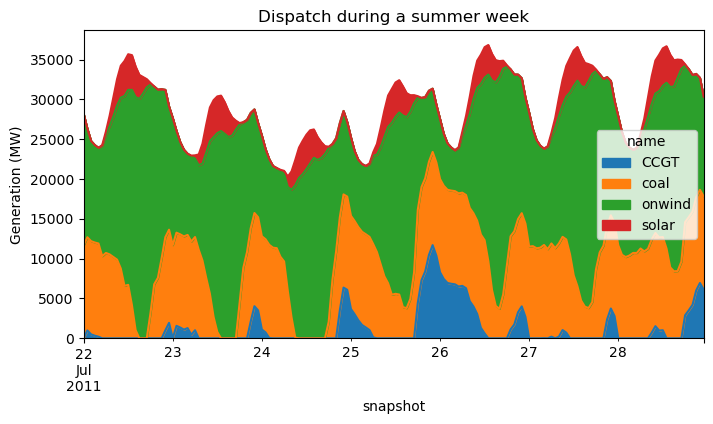

In [22]:
# dispatch time series for a week in summer
summer = dispatch.loc["2011-07-22 00:00":"2011-07-28 23:00"]

summer.plot.area(figsize=(8,4))

plt.ylabel("Generation (MW)")
plt.title("Dispatch during a summer week")
plt.show()

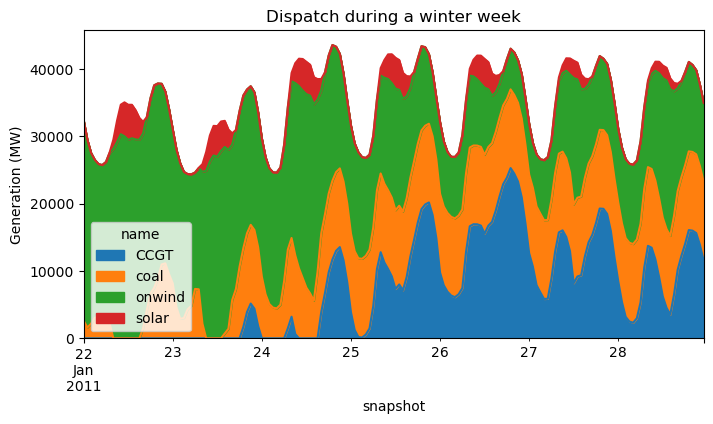

In [23]:
# dispatch time series for a week in winter
winter = dispatch.loc["2011-01-22 00:00":"2011-01-28 23:00"]

winter.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch during a winter week")
plt.show()

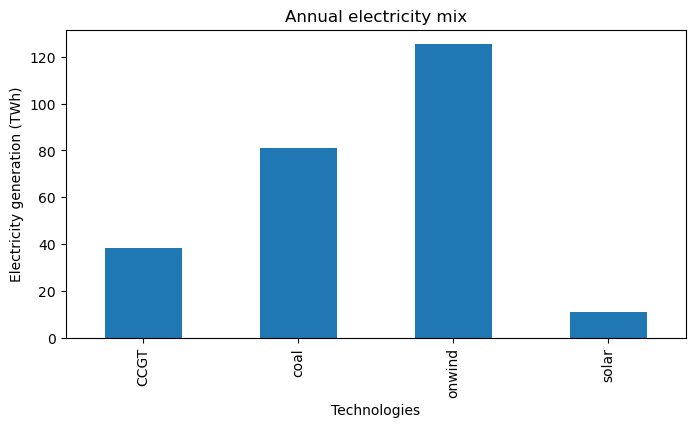

In [24]:
# Plot the annual electricity mix
annual_generation = dispatch.sum()
annual_generation_TWh = annual_generation / 1e6 # convert to TWh
annual_generation_TWh.plot(kind="bar", figsize=(8,4))
plt.ylabel("Electricity generation (TWh)")
plt.xlabel("Technologies")
plt.title("Annual electricity mix")
plt.show()

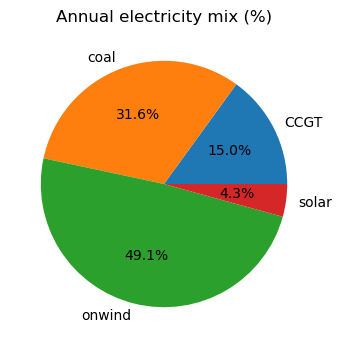

In [25]:
# Plot the annual electricity mix in %
mix_percent = 100 * annual_generation / annual_generation.sum()
mix_percent.plot(kind="pie", autopct="%1.1f%%", figsize=(8,4))
plt.ylabel("")
plt.title("Annual electricity mix (%)")
plt.show()

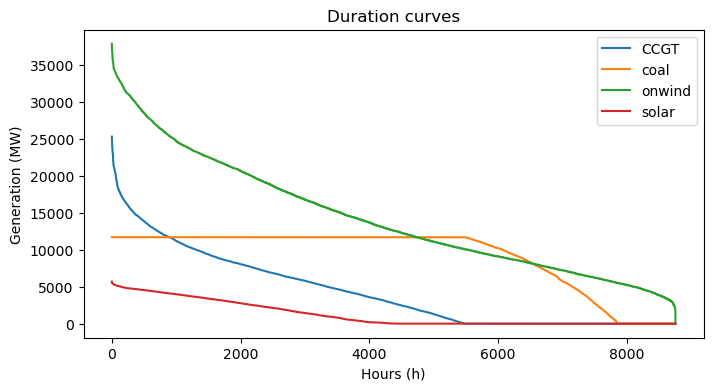

In [26]:
# Plot the duration curves 
# Describe the generation of each technology sorted from highest to lowest output over the year

plt.figure(figsize=(8,4))

for tech in dispatch.columns:
    dispatch[tech].sort_values(ascending=False).reset_index(drop=True).plot(label=tech)

plt.xlabel("Hours (h)")
plt.ylabel("Generation (MW)")
plt.title("Duration curves")
plt.legend()
plt.show()

## Question B 

- Investigate how sensitive your results are to the interannual variability of solar and wind generation.
Plot the average capacity and variability obtained for every generator using different weather years.

In [27]:
#Cost data

year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}

costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]

In [28]:
# Cost Functions 

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity_values = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity_values + costs["FOM"] / 100) * costs["investment"]

In [29]:
# Load & Weather data
data_solar = pd.read_csv('data/pv_optimal.csv', sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv', sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

country = 'ESP'

In [30]:
# PART A #

# Network Setup 
n = pypsa.Network()

hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')
n.set_snapshots(hours.values)

n.add("Bus", "Spain electricity")

n.add("Load",
      "demand",
      bus="Spain electricity",
      p_set=data_el[country].values)


In [31]:
# Capacity Factors 

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]

In [32]:
# Generators

n.add("Generator", "CCGT",
      bus="Spain electricity",
      carrier="CCGT",
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"],
      efficiency=costs.at["CCGT", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=25300)

n.add("Generator", "coal",
      bus="Spain electricity",
      carrier="coal",
      capital_cost=costs.at["coal", "capital_cost"],
      marginal_cost=costs.at["coal", "marginal_cost"],
      efficiency=costs.at["coal", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=11700)

n.add("Generator", "onwind",
      bus="Spain electricity",
      carrier="onwind",
      p_max_pu=CF_wind.values,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      efficiency=costs.at["onwind", "efficiency"],
      p_nom_extendable=True)

n.add("Generator", "solar",
      bus="Spain electricity",
      carrier="solar",
      p_max_pu=CF_solar.values,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      efficiency=costs.at["solar", "efficiency"],
      p_nom_extendable=True)

In [33]:
# Fix & Optimize 

for df in [n.buses, n.loads, n.generators]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n.optimize(solver_name="highs")

print("\nOptimal capacities (GW):")
print(n.generators.p_nom_opt / 1000)

Index(['Spain electricity'], dtype='str', name='name')
Index(['CCGT', 'coal', 'onwind', 'solar'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 93.74it/s]
INFO:linopy.io: Writing time: 0.35s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78846 duals
Objective: 1.85e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Optimal capacities (GW):
name
CCGT      25.300000
coal      11.700000
onwind    70.337209
solar      7.242738
Name: p_nom_opt, dtype: float64


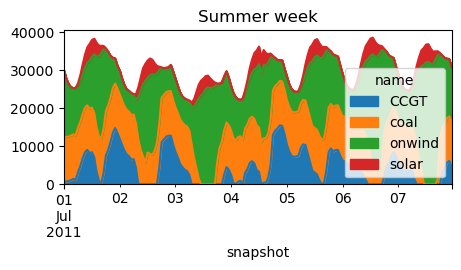

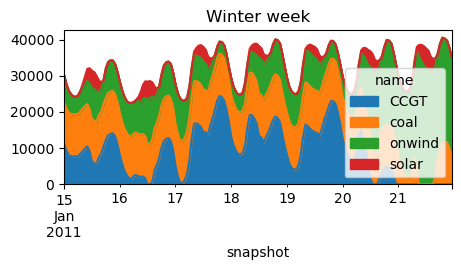

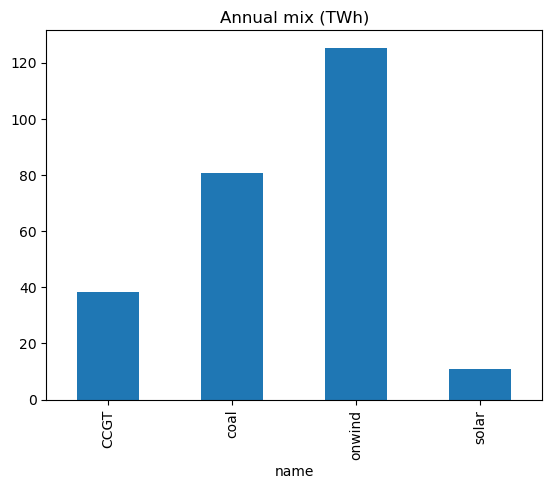

In [34]:
# Plot results

dispatch = n.generators_t.p

dispatch.loc["2011-07-01":"2011-07-07"].plot.area(figsize=(5, 2))
plt.title("Summer week")
plt.show()

dispatch.loc["2011-01-15":"2011-01-21"].plot.area(figsize=(5, 2))
plt.title("Winter week")
plt.show()

(dispatch.sum() / 1e6).plot(kind="bar")
plt.title("Annual mix (TWh)")
plt.show()

In [35]:
# PART B #

# Setup Loop

simulation_years = range(1979, 2018)

capacity_results = pd.DataFrame(index=simulation_years,
                                columns=["CCGT", "coal", "onwind", "solar"])

load_2015 = data_el[data_el.index.year == 2015][country].values[:8760]


In [ ]:
# Simulation Loop

for year in simulation_years:

    #print(f"Running year: {year}")

    n = pypsa.Network()

    snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="h")
    snapshots = snapshots[~((snapshots.month == 2) & (snapshots.day == 29))]
    n.set_snapshots(snapshots)

    n.add("Bus", "electricity bus")

n.add("Load", "load",
      bus="electricity bus",
      p_set=data_el[country].values)

# Simulation Loop

for year in simulation_years:

      #print(f"Running year: {year}")

      n = pypsa.Network()

      snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="h")
      snapshots = snapshots[~((snapshots.month == 2) & (snapshots.day == 29))]
      n.set_snapshots(snapshots)

      n.add("Bus", "electricity bus")

      n.add("Load", "load",
              bus="electricity bus",
              p_set=data_el[country].values)

      wind_year = data_wind[data_wind.index.year == year][country]
      solar_year = data_solar[data_solar.index.year == year][country]

      wind_year = wind_year[~((wind_year.index.month == 2) & (wind_year.index.day == 29))].values
      solar_year = solar_year[~((solar_year.index.month == 2) & (solar_year.index.day == 29))].values

      n.add("Generator", "CCGT",
              bus="electricity bus",
              carrier="CCGT",
              capital_cost=costs.at["CCGT", "capital_cost"],
              marginal_cost=costs.at["CCGT", "marginal_cost"],
              p_nom_extendable=True,
              p_nom_max=25300)

      n.add("Generator", "coal",
              bus="electricity bus",
              carrier="coal",
              capital_cost=costs.at["coal", "capital_cost"],
              marginal_cost=costs.at["coal", "marginal_cost"],
              p_nom_extendable=True,
              p_nom_max=11700)

      n.add("Generator", "onwind",
              bus="electricity bus",
              carrier="onwind",
              p_max_pu=wind_year,
              capital_cost=costs.at["onwind", "capital_cost"],
              marginal_cost=costs.at["onwind", "marginal_cost"],
              p_nom_extendable=True)

      n.add("Generator", "solar",
              bus="electricity bus",
              carrier="solar",
              p_max_pu=solar_year,
              capital_cost=costs.at["solar", "capital_cost"],
              marginal_cost=costs.at["solar", "marginal_cost"],
              p_nom_extendable=True)

      for df in [n.buses, n.loads, n.generators]:
            for col in df.columns:
                  if "ArrowStringArray" in str(type(df[col].array)):
                        df[col] = df[col].astype("object")

      n.optimize(solver_name="highs")

      capacity_results.loc[year] = n.generators.p_nom_opt / 1000
    solar_year = data_solar[data_solar.index.year == year][country]

wind_year = wind_year[~((wind_year.index.month == 2) & (wind_year.index.day == 29))].values
solar_year = solar_year[~((solar_year.index.month == 2) & (solar_year.index.day == 29))].values

    n.add("Generator", "CCGT",
          bus="electricity bus",
          carrier="CCGT",
          capital_cost=costs.at["CCGT", "capital_cost"],
          marginal_cost=costs.at["CCGT", "marginal_cost"],
          p_nom_extendable=True,
          p_nom_max=25300)

    n.add("Generator", "coal",
          bus="electricity bus",
          carrier="coal",
          capital_cost=costs.at["coal", "capital_cost"],
          marginal_cost=costs.at["coal", "marginal_cost"],
          p_nom_extendable=True,
          p_nom_max=11700)

    n.add("Generator", "onwind",
          bus="electricity bus",
          carrier="onwind",
          p_max_pu=wind_year,
          capital_cost=costs.at["onwind", "capital_cost"],
          marginal_cost=costs.at["onwind", "marginal_cost"],
          p_nom_extendable=True)

    n.add("Generator", "solar",
          bus="electricity bus",
          carrier="solar",
          p_max_pu=solar_year,
          capital_cost=costs.at["solar", "capital_cost"],
          marginal_cost=costs.at["solar", "marginal_cost"],
          p_nom_extendable=True)

    for df in [n.buses, n.loads, n.generators]:
        for col in df.columns:
            if "ArrowStringArray" in str(type(df[col].array)):
                df[col] = df[col].astype("object")

    n.optimize(solver_name="highs")

# Simulation Loop

for year in simulation_years:
      #print(f"Running year: {year}")
      n = pypsa.Network()
      snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="h")
      snapshots = snapshots[~((snapshots.month == 2) & (snapshots.day == 29))]
      n.set_snapshots(snapshots)
      n.add("Bus", "electricity bus")
      n.add("Load", "load",
              bus="electricity bus",
              p_set=data_el[country].values)
      wind_year = data_wind[data_wind.index.year == year][country]
      solar_year = data_solar[data_solar.index.year == year][country]
      wind_year = wind_year[~((wind_year.index.month == 2) & (wind_year.index.day == 29))].values
      solar_year = solar_year[~((solar_year.index.month == 2) & (solar_year.index.day == 29))].values
      n.add("Generator", "CCGT",
              bus="electricity bus",
              carrier="CCGT",
              capital_cost=costs.at["CCGT", "capital_cost"],
              marginal_cost=costs.at["CCGT", "marginal_cost"],
              p_nom_extendable=True,
              p_nom_max=25300)
      n.add("Generator", "coal",
              bus="electricity bus",
              carrier="coal",
              capital_cost=costs.at["coal", "capital_cost"],
              marginal_cost=costs.at["coal", "marginal_cost"],
              p_nom_extendable=True,
              p_nom_max=11700)
      n.add("Generator", "onwind",
              bus="electricity bus",
              carrier="onwind",
              p_max_pu=wind_year,
              capital_cost=costs.at["onwind", "capital_cost"],
              marginal_cost=costs.at["onwind", "marginal_cost"],
              p_nom_extendable=True)
      n.add("Generator", "solar",
              bus="electricity bus",
              carrier="solar",
              p_max_pu=solar_year,
              capital_cost=costs.at["solar", "capital_cost"],
              marginal_cost=costs.at["solar", "marginal_cost"],
              p_nom_extendable=True)
      for df in [n.buses, n.loads, n.generators]:
            for col in df.columns:
                  if "ArrowStringArray" in str(type(df[col].array)):
                        df[col] = df[col].astype("object")
      n.optimize(solver_name="highs")
      capacity_results.loc[year] = n.generators.p_nom_opt / 1000


IndentationError: unexpected indent (2395489713.py, line 19)

In [ ]:
# Results

capacity_results = capacity_results.astype(float)

mean_capacity = capacity_results.mean()
std_capacity = capacity_results.std()

print("\nAverage capacities (GW):")
print(mean_capacity)

print("\nVariability (std dev, GW):")
print(std_capacity)


Average capacities (GW):
CCGT      25.300000
coal      10.057231
onwind    46.188682
solar     13.588162
dtype: float64

Variability (std dev, GW):
CCGT      1.799578e-14
coal      1.656811e+00
onwind    1.034219e+01
solar     7.595048e+00
dtype: float64


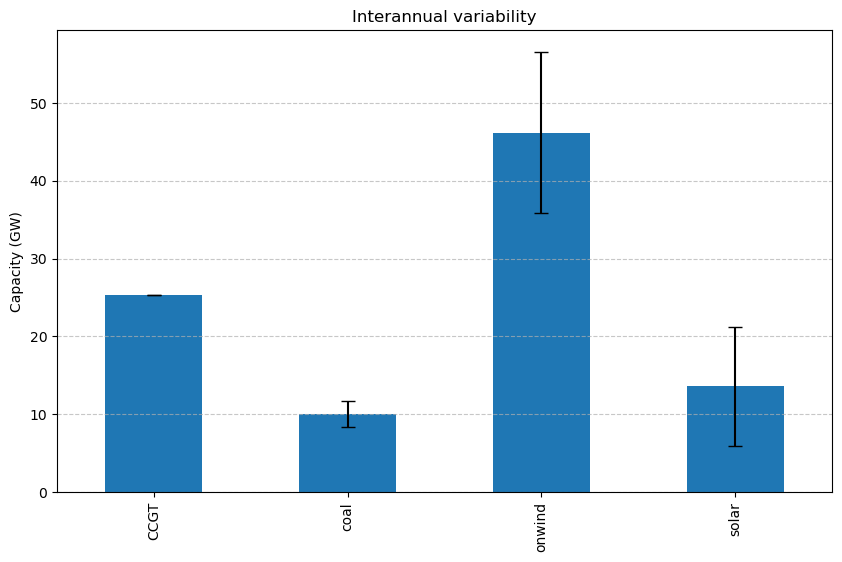

In [ ]:
# Final plot

plt.figure(figsize=(10, 6))

mean_capacity.plot(
    kind="bar",
    yerr=std_capacity,
    capsize=5
)

plt.title("Interannual variability")
plt.ylabel("Capacity (GW)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

<Figure size 1000x600 with 0 Axes>

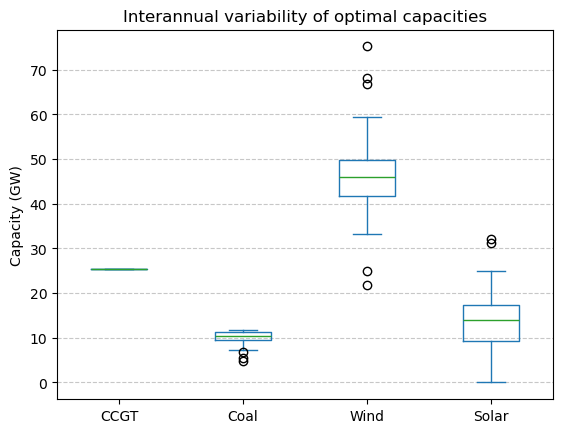

In [ ]:
# New plot: Box plot

plt.figure(figsize=(10, 6))

capacity_results.plot(kind="box")

plt.title("Interannual variability of optimal capacities")
plt.ylabel("Capacity (GW)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()




## Question C

- Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies your system is using to balance the renewable generation at different time scales (intraday, seasonal, etc.)

## Joint capacity and dispatch optimization

In [ ]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq=None)

In [ ]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
    "PHS", #adding the storage technology -- pumped hydro storage
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green", "brown"], # colors that represent each carrier
)

In [ ]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

In [ ]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=25300, # 25.3 GW
)

# coal
n.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=11700, # 11.7 GW
)

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Onshore wind
n.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Solar PV
n.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

# Pumped Hydro Storage
n.add(
    "StorageUnit",
    "PHS",
    bus="Spain electricity",
    carrier="PHS",
    max_hours=6,  # storage can discharge at full power for 6 hours
    capital_cost=costs.at["PHS", "capital_cost"],
    marginal_cost=costs.at["PHS", "marginal_cost"],
    # round-trip efficiency = charging efficiency * discharging efficiency
    efficiency_store=costs.at["PHS", "efficiency"]**0.5, # charging efficiency
    efficiency_dispatch=costs.at["PHS", "efficiency"]**0.5, # discharging efficiency
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)


# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

In [ ]:
for df in [n.buses, n.loads, n.generators, n.carriers, n.storage_units]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n.buses.index = pd.Index(n.buses.index.tolist(), dtype=object)
n.loads.index = pd.Index(n.loads.index.tolist(), dtype=object)
n.generators.index = pd.Index(n.generators.index.tolist(), dtype=object)
n.carriers.index = pd.Index(n.carriers.index.tolist(), dtype=object)
n.storage_units.index = pd.Index(n.storage_units.index.tolist(), dtype=object)

n.buses.index.name = "name"
n.loads.index.name = "name"
n.generators.index.name = "name"
n.carriers.index.name = "name"
n.storage_units.index.name = "name"

## Model PyPSA

In [ ]:
n.optimize(solver_name="highs")
# PyPS decides two things at the same time: capacity (how much technology to build) and dispatch (how much each generator produces in every hour of the year)

C:\Users\20221122\AppData\Local\Temp\ipykernel_68192\252832996.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Spain electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 230.79it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140167 duals
Objective: 1.61e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, Storag

('ok', 'optimal')

In [ ]:
# optimised capacities in GW
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
CCGT      25.300000
coal       3.101213
onwind    -0.000000
solar     66.734432
Name: p_nom_opt, dtype: float64

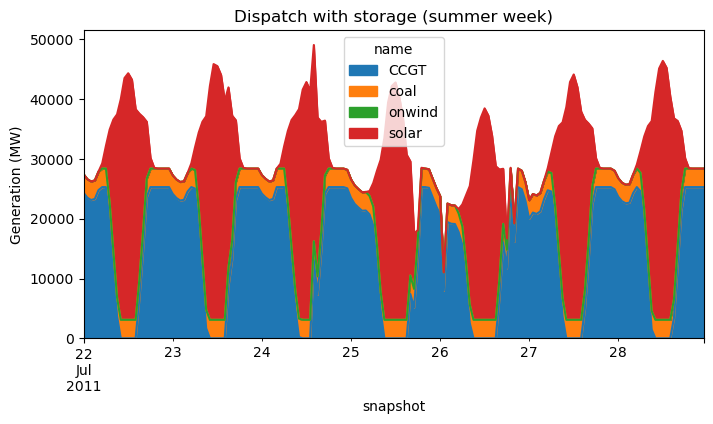

In [ ]:
dispatch = n.generators_t.p

summer = dispatch.loc["2011-07-22":"2011-07-28"]

summer.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch with storage (summer week)")
plt.show()

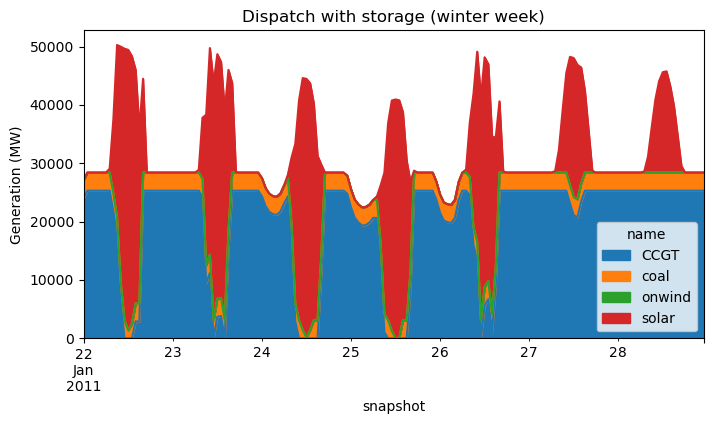

In [ ]:
dispatch = n.generators_t.p

summer = dispatch.loc["2011-01-22":"2011-01-28"]

summer.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch with storage (winter week)")
plt.show()

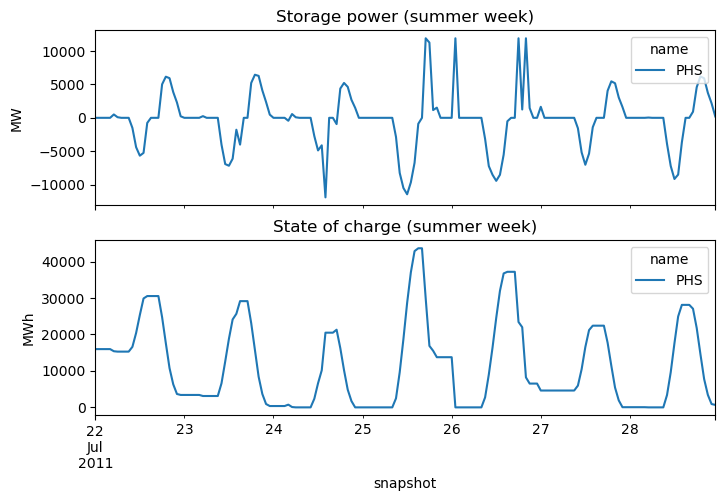

In [ ]:
soc = n.storage_units_t.state_of_charge

summer_soc = soc.loc["2011-07-22":"2011-07-28"]
summer_p = n.storage_units_t.p.loc["2011-07-22":"2011-07-28"]

fig, ax = plt.subplots(2,1, figsize=(8,5), sharex=True)

summer_p.plot(ax=ax[0])
ax[0].set_title("Storage power (summer week)")
ax[0].set_ylabel("MW")

summer_soc.plot(ax=ax[1])
ax[1].set_title("State of charge (summer week)")
ax[1].set_ylabel("MWh")

plt.show()

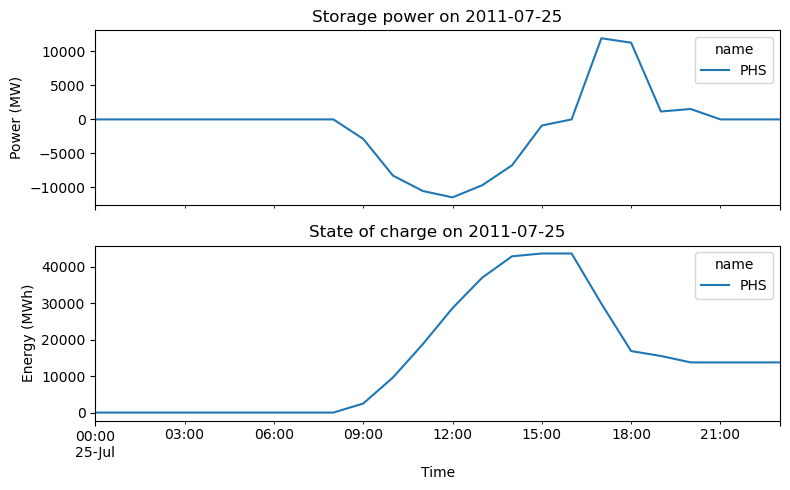

In [ ]:
day = "2011-07-25"

storage_power_day = n.storage_units_t.p.loc[day]
soc_day = n.storage_units_t.state_of_charge.loc[day]

fig, ax = plt.subplots(2, 1, figsize=(8,5), sharex=True)

storage_power_day.plot(ax=ax[0])
ax[0].set_title(f"Storage power on {day}")
ax[0].set_ylabel("Power (MW)")

soc_day.plot(ax=ax[1])
ax[1].set_title(f"State of charge on {day}")
ax[1].set_ylabel("Energy (MWh)")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

## Question D

- Connect your country to at least three neighbouring countries using HVAC lines, making sure that the network includes at least one closed cycle. Look for information on the existing capacities of those interconnectors and set the capacities fixed. Assume a voltage level of 400 kV and a unitary reactance x=0.1. You can assume that the generation capacities in the neighbouring countries are fixed or co-optimise the whole system. Optimise the whole system, assuming linearised AC power flow (DC approximation) and discuss the results.